In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# access project modules
sys.path.append("..")

from main import get_simdata2

In [2]:
print("===== Small Controlled Experiment =====")

nodes = 5
demodulators = 1

print("\nBaseline:")
baseline = get_simdata2(nodes, demodulators, False, False)

print("\nEarly Decode + Drop:")
early = get_simdata2(nodes, demodulators, True, True)

===== Small Controlled Experiment =====

Baseline:
Nodes: 5
Tracked TXs: 1
Decoded hdr+pld: 1
Collided hdr+pld: 0
Decoded bytes: 20
Header drops: 0
------

Early Decode + Drop:
Nodes: 5
Tracked TXs: 1
Decoded hdr+pld: 1
Collided hdr+pld: 0
Decoded bytes: 20
Header drops: 0
------


In [3]:
print("\n===== Demodulator Sensitivity Test =====")

demodulators = [1,2,5,10,20,50,100,500,1000]
nodes = 2000

baseline_results = []
early_results = []

for d in demodulators:
    
    print("\nDemodulators:", d)

    x = get_simdata2(nodes, d, False, False)
    baseline_results.append(x[3])

    x = get_simdata2(nodes, d, True, True)
    early_results.append(x[3])


===== Demodulator Sensitivity Test =====

Demodulators: 1
Nodes: 2000
Tracked TXs: 1
Decoded hdr+pld: 0
Collided hdr+pld: 1
Decoded bytes: 0
Header drops: 0
------
Nodes: 2000
Tracked TXs: 1
Decoded hdr+pld: 0
Collided hdr+pld: 1
Decoded bytes: 0
Header drops: 0
------

Demodulators: 2
Nodes: 2000
Tracked TXs: 2
Decoded hdr+pld: 0
Collided hdr+pld: 2
Decoded bytes: 0
Header drops: 0
------
Nodes: 2000
Tracked TXs: 2
Decoded hdr+pld: 0
Collided hdr+pld: 2
Decoded bytes: 0
Header drops: 0
------

Demodulators: 5
Nodes: 2000
Tracked TXs: 5
Decoded hdr+pld: 0
Collided hdr+pld: 5
Decoded bytes: 0
Header drops: 0
------
Nodes: 2000
Tracked TXs: 5
Decoded hdr+pld: 0
Collided hdr+pld: 5
Decoded bytes: 0
Header drops: 0
------

Demodulators: 10
Nodes: 2000
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 10
Decoded bytes: 0
Header drops: 0
------
Nodes: 2000
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 10
Decoded bytes: 0
Header drops: 0
------

Demodulators: 20
Nodes: 2000
Tracked

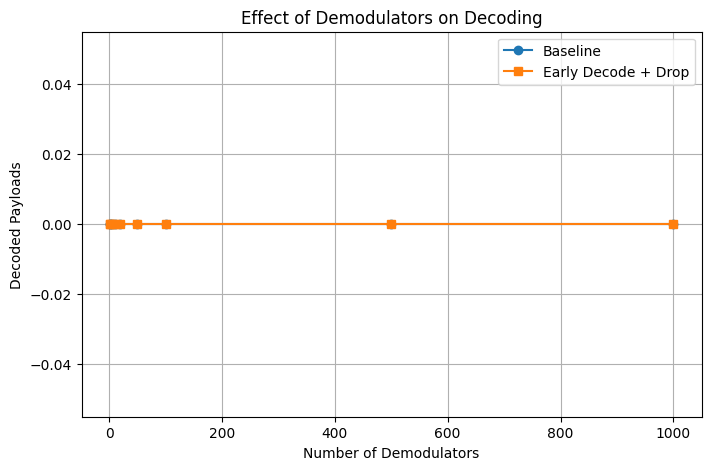

In [4]:
plt.figure(figsize=(8,5))

plt.plot(demodulators, baseline_results, marker='o', label="Baseline")
plt.plot(demodulators, early_results, marker='s', label="Early Decode + Drop")

plt.xlabel("Number of Demodulators")
plt.ylabel("Decoded Payloads")
plt.title("Effect of Demodulators on Decoding")

plt.legend()
plt.grid(True)
plt.show()

In [6]:
print("\n===== Heavy Load Experiment =====")

nodeLoads = np.logspace(2,4,20)   # 100 → 10000 nodes
demodulators = [10,100,1000]

baseline = {}
early = {}

for d in demodulators:

    decoded_base = []
    decoded_early = []

    print("\nTesting with", d, "demodulators")

    for n in nodeLoads:

        x = get_simdata2(n, d, False, False)
        decoded_base.append(x[3])

        x = get_simdata2(n, d, True, True)
        decoded_early.append(x[3])

    baseline[d] = decoded_base
    early[d] = decoded_early


===== Heavy Load Experiment =====

Testing with 10 demodulators
Nodes: 100
Tracked TXs: 10
Decoded hdr+pld: 10
Collided hdr+pld: 0
Decoded bytes: 200
Header drops: 0
------
Nodes: 100
Tracked TXs: 10
Decoded hdr+pld: 8
Collided hdr+pld: 0
Decoded bytes: 160
Header drops: 0
------
Nodes: 127
Tracked TXs: 10
Decoded hdr+pld: 8
Collided hdr+pld: 0
Decoded bytes: 160
Header drops: 0
------
Nodes: 127
Tracked TXs: 10
Decoded hdr+pld: 10
Collided hdr+pld: 0
Decoded bytes: 200
Header drops: 0
------
Nodes: 162
Tracked TXs: 10
Decoded hdr+pld: 6
Collided hdr+pld: 0
Decoded bytes: 120
Header drops: 0
------
Nodes: 162
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 4
Decoded bytes: 20
Header drops: 0
------
Nodes: 206
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 4
Decoded bytes: 20
Header drops: 0
------
Nodes: 206
Tracked TXs: 10
Decoded hdr+pld: 3
Collided hdr+pld: 3
Decoded bytes: 60
Header drops: 0
------
Nodes: 263
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 3
Decode

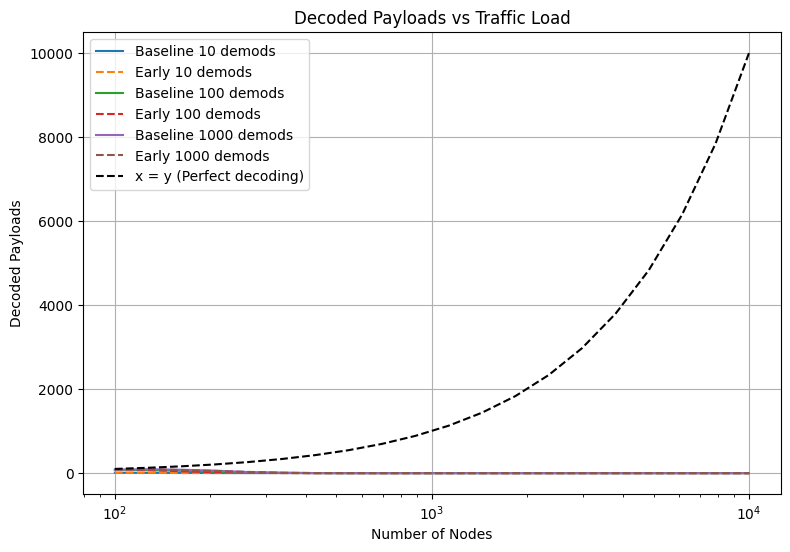

In [7]:
plt.figure(figsize=(9,6))

for d in demodulators:

    plt.plot(nodeLoads, baseline[d], label=f"Baseline {d} demods")
    plt.plot(nodeLoads, early[d], linestyle="--", label=f"Early {d} demods")

# theoretical perfect decoding
plt.plot(nodeLoads, nodeLoads, 'k--', label="x = y (Perfect decoding)")

plt.xscale("log")

plt.xlabel("Number of Nodes")
plt.ylabel("Decoded Payloads")
plt.title("Decoded Payloads vs Traffic Load")

plt.legend()
plt.grid(True)
plt.show()

In [8]:
print("\n===== Runtime Test =====")

nodes = 1000
demodulators = 100

simTimes = [228,456,912]

runtime_results = []

for t in simTimes:

    start = time.time()

    get_simdata2(nodes, demodulators, False, False)

    runtime = time.time() - start

    runtime_results.append(runtime)

    print("simTime:", t, "Runtime:", runtime, "seconds")


===== Runtime Test =====
Nodes: 1000
Tracked TXs: 100
Decoded hdr+pld: 0
Collided hdr+pld: 94
Decoded bytes: 0
Header drops: 0
------
simTime: 228 Runtime: 0.9531862735748291 seconds
Nodes: 1000
Tracked TXs: 100
Decoded hdr+pld: 0
Collided hdr+pld: 95
Decoded bytes: 0
Header drops: 0
------
simTime: 456 Runtime: 0.9165914058685303 seconds
Nodes: 1000
Tracked TXs: 100
Decoded hdr+pld: 0
Collided hdr+pld: 95
Decoded bytes: 0
Header drops: 0
------
simTime: 912 Runtime: 0.9169490337371826 seconds


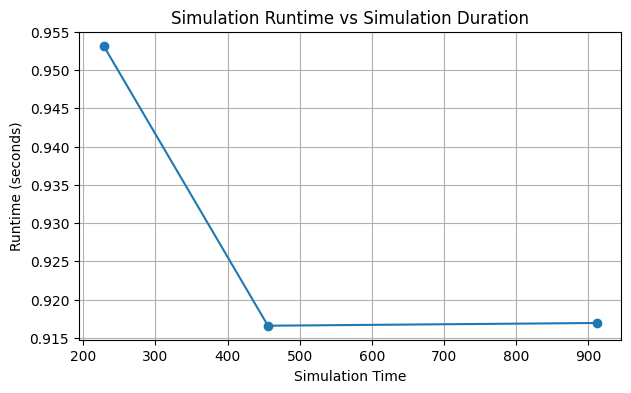

In [9]:
plt.figure(figsize=(7,4))

plt.plot(simTimes, runtime_results, marker='o')

plt.xlabel("Simulation Time")
plt.ylabel("Runtime (seconds)")
plt.title("Simulation Runtime vs Simulation Duration")

plt.grid(True)
plt.show()